# Notebook 1: Exploratory Data Analysis (EDA)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully.


In [2]:
%pip install pandas numpy matplotlib seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 33.6 MB/s  0:00:005.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 37.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 37.6 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 43.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]━  9/10 [seaborn]ib]
Note: you may need to restart the kernel to use updated packages.


In [4]:
lbnl_file_path = '../data/raw/MZVAV-1.csv'

df_lbnl = pd.read_csv(lbnl_file_path, parse_dates=['Datetime'], index_col='Datetime')

print(f"LBNL Dataset Shape: {df_lbnl.shape}")
display(df_lbnl.head())

LBNL Dataset Shape: (272160, 17)


,AHU: Supply Air Temperature,AHU: Supply Air Temperature Set Point,AHU: Outdoor Air Temperature,AHU: Mixed Air Temperature,AHU: Return Air Temperature,AHU: Supply Air Fan Status,AHU: Return Air Fan Status,AHU: Supply Air Fan Speed Control Signal,AHU: Return Air Fan Speed Control Signal,AHU: Outdoor Air Damper Control Signal,AHU: Return Air Damper Control Signal,AHU: Cooling Coil Valve Control Signal,AHU: Heating Coil Valve Control Signal,AHU: Supply Air Duct Static Pressure Set Point,AHU: Supply Air Duct Static Pressure,Occupancy Mode Indicator,Fault Detection Ground Truth
Datetime,,,,,,,,,,,,,,,,,
2017-01-30 00:00:00,68.00,55.04,32.00,68.00,75.20,0,0,0.0,0.0,0.0,0.0,0.0,0,0.04,0.0,0,0
2017-01-30 00:01:00,67.99,55.04,32.00,66.71,75.20,0,0,0.0,0.0,0.0,0.0,0.0,0,0.04,0.0,0,0
2017-01-30 00:02:00,67.99,55.04,-5.93,66.71,74.45,0,0,0.0,0.0,0.0,0.0,0.0,0,0.04,0.0,0,0
2017-01-30 00:03:00,67.99,55.04,-5.88,66.71,74.04,0,0,0.0,0.0,0.0,0.0,0.0,0,0.04,0.0,0,0
2017-01-30 00:04:00,67.99,55.04,-5.83,66.71,73.56,0,0,0.0,0.0,0.0,0.0,0.0,0,0.04,0.0,0,0


In [5]:
missing_data = df_lbnl.isnull().sum()
print("Missing Values per Column:")
print(missing_data[missing_data > 0]) 

print("\n" + "="*40 + "\n")

print("All Column Names in the Dataset:")
for col in df_lbnl.columns:
    print(f"- {col}")

Missing Values per Column:
Series([], dtype: int64)


All Column Names in the Dataset:
- AHU: Supply Air Temperature
- AHU: Supply Air Temperature Set Point
- AHU: Outdoor Air Temperature
- AHU: Mixed Air Temperature
- AHU: Return Air Temperature
- AHU: Supply Air Fan Status
- AHU: Return Air Fan Status
- AHU: Supply Air Fan Speed Control Signal
- AHU: Return Air Fan Speed Control Signal
- AHU: Outdoor Air Damper Control Signal  
- AHU: Return Air Damper Control Signal
- AHU: Cooling Coil Valve Control Signal
- AHU: Heating Coil Valve Control Signal
- AHU: Supply Air Duct Static Pressure Set Point
- AHU: Supply Air Duct Static Pressure
- Occupancy Mode Indicator
- Fault Detection Ground Truth


/var/folders/4w/f6lqt5t50f78r1q99rq96nd00000gp/T/ipykernel_8617/3218165431.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_lbnl, x='Fault Detection Ground Truth', palette='Set2')


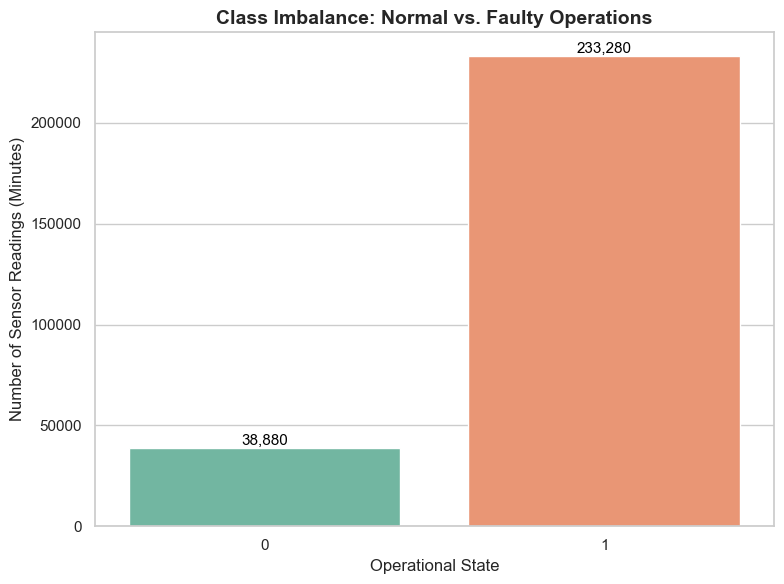

Class Distribution Percentages:
Fault Detection Ground Truth
1    85.71%
0    14.29%
Name: proportion, dtype: str


In [15]:
import os
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df_lbnl, x='Fault Detection Ground Truth', palette='Set2')

plt.title('Class Imbalance: Normal vs. Faulty Operations', fontsize=14, fontweight='bold')
plt.xlabel('Operational State', fontsize=12)
plt.ylabel('Number of Sensor Readings (Minutes)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black')

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/Figure_4_1_Class_Imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

counts = df_lbnl['Fault Detection Ground Truth'].value_counts(normalize=True) * 100
print("Class Distribution Percentages:")
print(counts.round(2).astype(str) + '%')

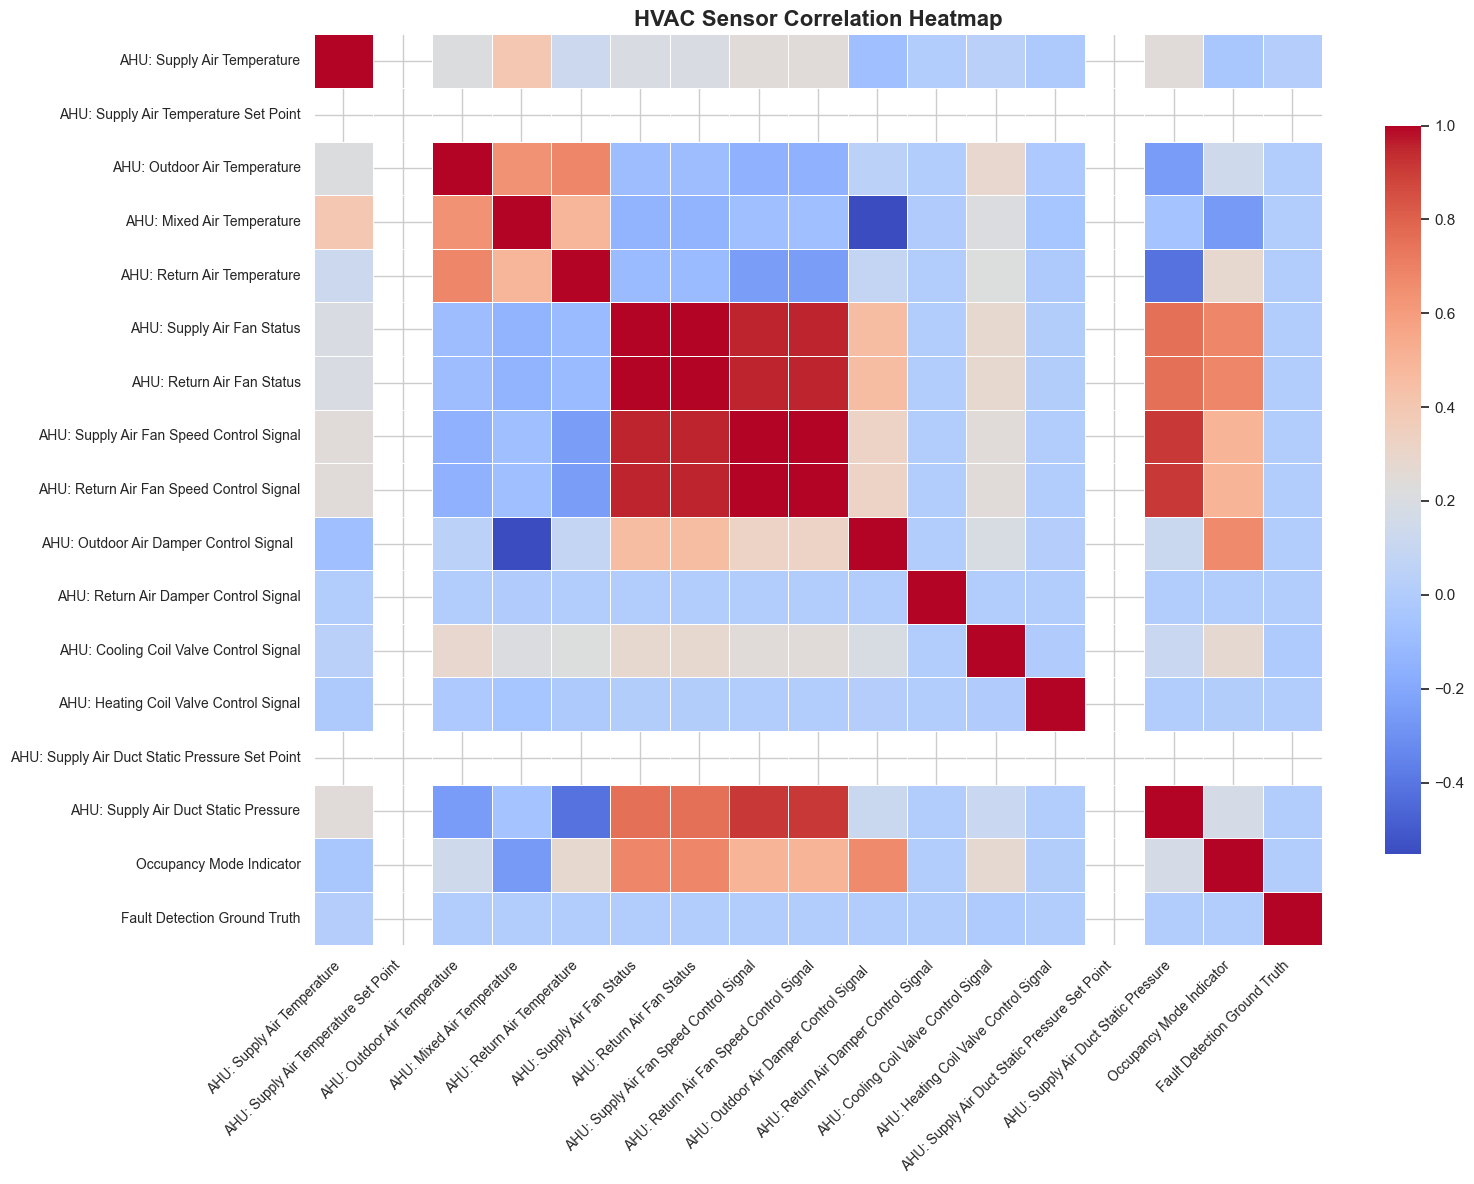

In [17]:
numeric_df = df_lbnl.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, 
            annot=False,          
            cmap='coolwarm',      
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('HVAC Sensor Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.savefig('../figures/Figure_4_2_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

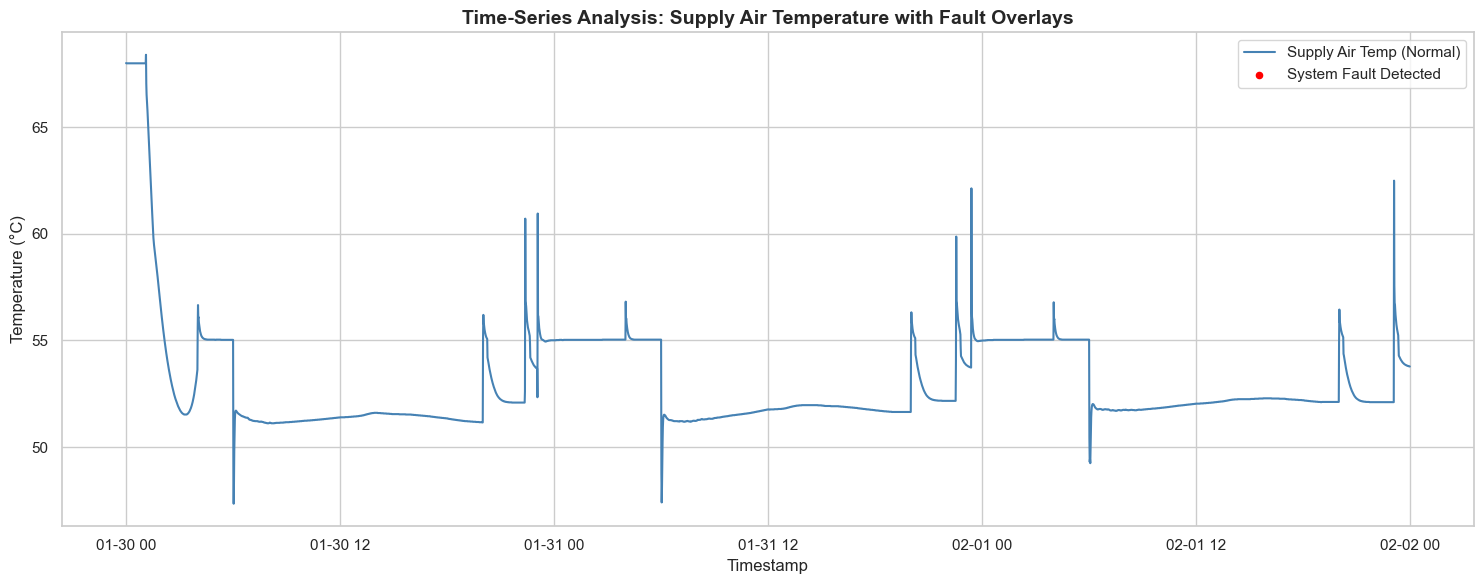

In [18]:
subset_df = df_lbnl.head(60 * 24 * 3) 

plt.figure(figsize=(15, 6))

plt.plot(subset_df.index, subset_df['AHU: Supply Air Temperature'], 
         label='Supply Air Temp (Normal)', color='steelblue', linewidth=1.5)

faults = subset_df[subset_df['Fault Detection Ground Truth'] == 1]

plt.scatter(faults.index, faults['AHU: Supply Air Temperature'], 
            color='red', label='System Fault Detected', zorder=5, s=20)

plt.title('Time-Series Analysis: Supply Air Temperature with Fault Overlays', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../figures/Figure_4_3_TimeSeries_Faults.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
stats_table = df_lbnl.describe().T 
stats_table = stats_table[['mean', 'std', 'min', 'max']] 

print("Table 4.1: Statistical Summary of HVAC Sensors")
display(stats_table.round(2))

Table 4.1: Statistical Summary of HVAC Sensors


,mean,std,min,max
AHU: Supply Air Temperature,53.76,2.55,44.95,72.03
AHU: Supply Air Temperature Set Point,55.04,0.00,55.04,55.04
AHU: Outdoor Air Temperature,48.36,20.15,-14.26,90.14
AHU: Mixed Air Temperature,65.00,7.41,22.61,78.72
AHU: Return Air Temperature,71.45,3.70,54.47,87.87
AHU: Supply Air Fan Status,0.67,0.47,0.00,1.00
AHU: Return Air Fan Status,0.67,0.47,0.00,1.00
AHU: Supply Air Fan Speed Control Signal,0.48,0.35,0.00,1.00
AHU: Return Air Fan Speed Control Signal,0.48,0.35,0.00,1.00
AHU: Outdoor Air Damper Control Signal,0.21,0.33,0.00,1.00
